<a href="https://colab.research.google.com/github/MPEC041/DS-ML/blob/main/DS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sudalairajkumar/covid19-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid19-in-india' dataset.
Path to dataset files: /kaggle/input/covid19-in-india


In [4]:
import os
print(os.listdir(path))

['StatewiseTestingDetails.csv', 'covid_vaccine_statewise.csv', 'covid_19_india.csv']


In [5]:
import pandas as pd
file_path=os.path.join(path,"covid_19_india.csv")
df=pd.read_csv(file_path)

df.head(3)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2


In [6]:
print("shape",df.shape)
print("columns",df.columns)
print("dtypes",df.dtypes)

shape (18110, 9)
columns Index(['Sno', 'Date', 'Time', 'State/UnionTerritory',
       'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured',
       'Deaths', 'Confirmed'],
      dtype='object')
dtypes Sno                          int64
Date                        object
Time                        object
State/UnionTerritory        object
ConfirmedIndianNational     object
ConfirmedForeignNational    object
Cured                        int64
Deaths                       int64
Confirmed                    int64
dtype: object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB


In [8]:
df.isnull().sum()

,0
Sno,0
Date,0
Time,0
State/UnionTerritory,0
ConfirmedIndianNational,0
ConfirmedForeignNational,0
Cured,0
Deaths,0
Confirmed,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3
...,...,...,...,...,...,...,...,...,...
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812


In [10]:
df["Date"]=pd.to_datetime(df["Date"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Sno                       18110 non-null  int64         
 1   Date                      18110 non-null  datetime64[ns]
 2   Time                      18110 non-null  object        
 3   State/UnionTerritory      18110 non-null  object        
 4   ConfirmedIndianNational   18110 non-null  object        
 5   ConfirmedForeignNational  18110 non-null  object        
 6   Cured                     18110 non-null  int64         
 7   Deaths                    18110 non-null  int64         
 8   Confirmed                 18110 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 1.2+ MB


In [12]:
df["Recovered"]=df["Cured"]

In [13]:
df["Active"]=df["Confirmed"]-df["Cured"]-df["Deaths"]

In [14]:
df.tail(3)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,Recovered,Active
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462,334650,444
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812,1685492,545
18109,18110,2021-08-11,8:00 AM,West Bengal,-,-,1506532,18252,1534999,1506532,10215


In [15]:
df.sample(10)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,Recovered,Active
14675,14676,2021-05-08,8:00 AM,Manipur,-,-,30378,449,34333,30378,3506
10704,10705,2021-01-18,8:00 AM,Gujarat,-,-,245107,4365,255872,245107,6400
10000,10001,2020-12-29,8:00 AM,Puducherry,-,-,37040,631,38028,37040,357
48,49,2020-03-05,6:00 PM,Rajasthan,1,14,0,0,15,0,15
1288,1289,2020-04-25,5:00 PM,Arunachal Pradesh,-,-,1,0,1,1,0
12740,12741,2021-03-15,8:00 AM,Tamil Nadu,-,-,842309,12547,859726,842309,4870
17312,17313,2021-07-20,8:00 AM,Tamil Nadu,-,-,2476339,33752,2537373,2476339,27282
1678,1679,2020-05-07,8:00 AM,Dadra and Nagar Haveli and Daman and Diu,-,-,0,0,1,0,1
13949,13950,2021-04-18,8:00 AM,Karnataka,-,-,1009549,13270,1141998,1009549,119179
5383,5384,2020-08-20,8:00 AM,Himachal Pradesh,-,-,2992,19,4411,2992,1400


In [23]:
state_data = (
    df.groupby("State/UnionTerritory")[["Confirmed","Deaths","Recovered","Active"]]
    .max()
    .reset_index()
    )

In [24]:

state_data["Recovery Rate"]=state_data["Recovered"]/state_data["Confirmed"].replace(0,pd.NA)*100


In [25]:
state_data["Deaths_Rate"]=state_data["Deaths"]/state_data["Confirmed"].replace(0,pd.NA)*100

In [19]:
state_data.head()

,State/UnionTerritory,Confirmed,Deaths,Recovered,Active,Recovery Rate,Deaths_Rate
0,Andaman and Nicobar Islands,7548,129,7412,1154,98.198198,1.709062
1,Andhra Pradesh,1985182,13564,1952736,211554,98.365591,0.683262
2,Arunachal Pradesh,50605,248,47821,4465,94.498567,0.490070
3,Assam,576149,5420,559684,56295,97.142232,0.940729
4,Bihar,725279,9646,715352,115152,98.631285,1.329971


In [20]:
state_data["Recovery Rate"] = state_data["Recovery Rate"].round(2)
state_data["Deaths_Rate"] = state_data["Deaths_Rate"].round(2)

In [21]:
state_data.head(3)

,State/UnionTerritory,Confirmed,Deaths,Recovered,Active,Recovery Rate,Deaths_Rate
0,Andaman and Nicobar Islands,7548,129,7412,1154,98.20,1.71
1,Andhra Pradesh,1985182,13564,1952736,211554,98.37,0.68
2,Arunachal Pradesh,50605,248,47821,4465,94.50,0.49


/tmp/ipykernel_3036/2474622275.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3036/2474622275.py:4: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


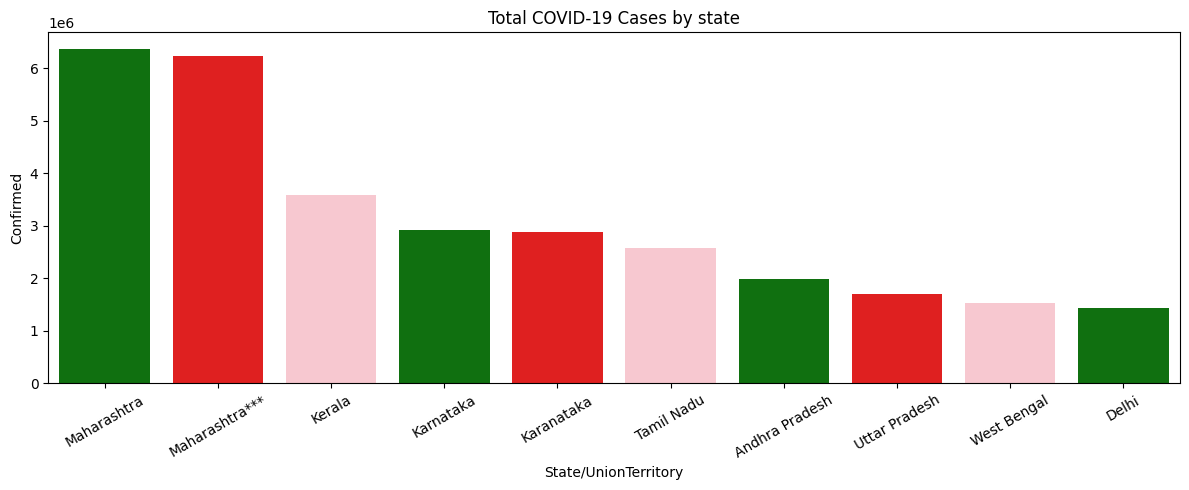

In [27]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5,))
sns.barplot(
    data = state_data.sort_values("Confirmed",ascending=False).head(10),
    x = "State/UnionTerritory",
    y = "Confirmed",
    palette=["green","red","pink"]
)
plt.title("Total COVID-19 Cases by state")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3036/2300913682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3036/2300913682.py:3: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


<Axes: xlabel='State/UnionTerritory', ylabel='Recovery Rate'>

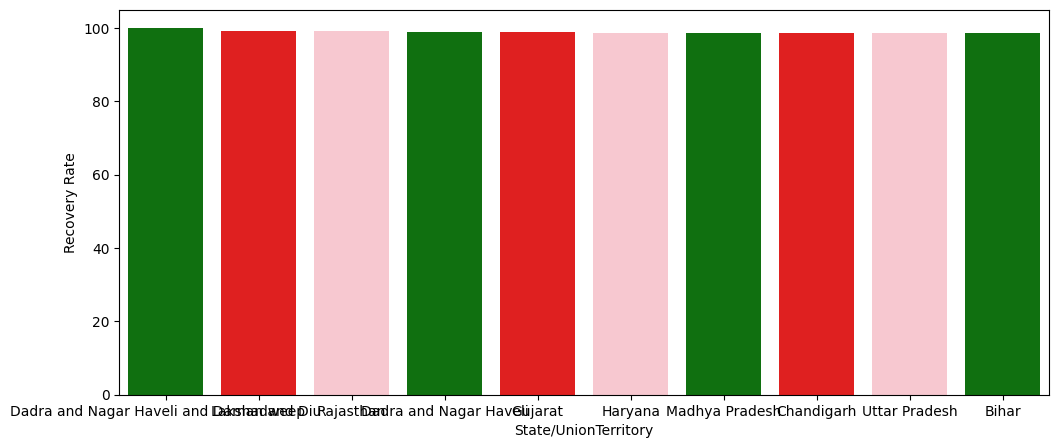

In [28]:
rate_data=state_data.sort_values("Recovery Rate",ascending=False).head(10)
plt.figure(figsize=(12,5,))
sns.barplot(
    data = rate_data,
    x = "State/UnionTerritory",
    y = "Recovery Rate",
    palette=["green","red","pink"]
)

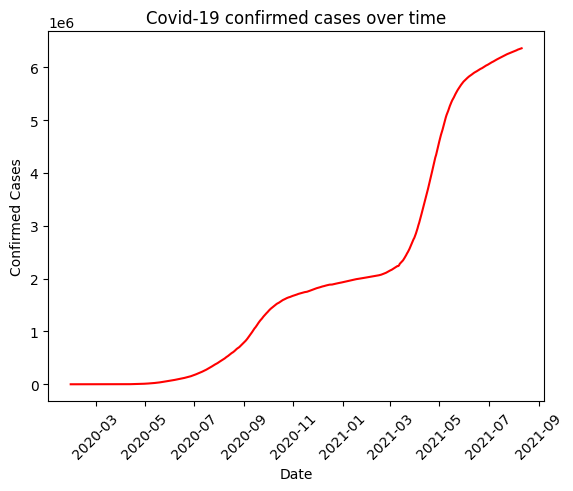

In [35]:
daily_cases=(
    df.groupby("Date")[["Confirmed"]].max().reset_index()
)
sns.lineplot(
    data=daily_cases,
    x="Date",
    y="Confirmed",
   color="red"
)
plt.title("Covid-19 confirmed cases over time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()